# 6. Proyecto potabilidad del Agua

# 🚰 Predicción de Potabilidad del Agua — Notebook Completo con SMOTE

Flujo completo de Machine Learning:
1. **EDA** — Análisis Exploratorio
2. **Preprocessing** — Imputación MICE + VIF + **SMOTE** + Escalado
3. **Models** — 5 modelos con GridSearchCV
4. **Evaluation** — Boxplot + Tabla comparativa
5. **Best Model** — ROC, Matriz de Confusión, Importancia
6. **Thresholds** — Youden, Riesgo, Financiero
7. **Export** — joblib + metadata
8. **Streamlit App** — Despliegue interactivo

---
## 📦 Imports Globales y Configuración
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
# 🔍 CAPÍTULO 1: Análisis Exploratorio de Datos (EDA)
---

## 1.1 Carga del Dataset

In [2]:
df = pd.read_csv('water_potability_clean.csv')

print('=' * 65)
print('=== DATASET: POTABILIDAD DEL AGUA ===')
print('=' * 65)
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\n📋 Primeras 5 filas:')
display(df.head())

print('\n📊 Información general:')
df.info()

=== DATASET: POTABILIDAD DEL AGUA ===
Dimensiones: 3276 filas × 10 columnas

📋 Primeras 5 filas:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



📊 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


**📝 Interpretación:** El dataset contiene 3276 muestras con 9 variables predictoras (químicas y físicas del agua) y 1 variable objetivo (Potability). Se observan valores nulos en `ph`, `Sulfate` y `Trihalomethanes`, lo que justifica el uso de imputación iterativa (MICE) en el preprocesamiento.

## 1.2 Análisis de Valores Nulos

=== ANÁLISIS DE VALORES NULOS ===


,Datos faltantes,Porcentaje (%)
ph,491,14.99
Sulfate,781,23.84
Trihalomethanes,162,4.95


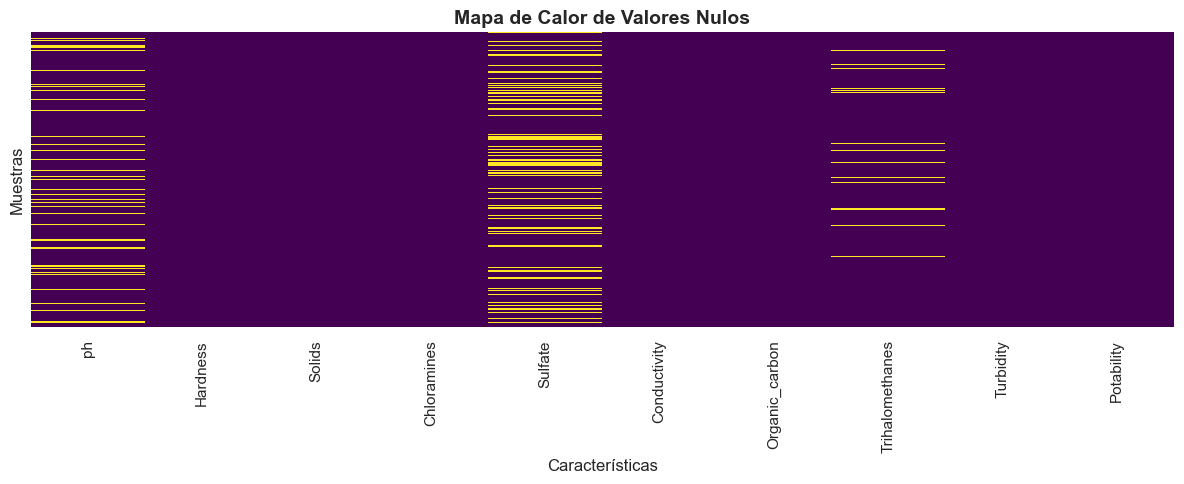

In [3]:
missing_values = df.isna().sum()
total_rows = df.shape[0]
missing_vars = missing_values[missing_values > 0]

missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_vars,
    'Porcentaje (%)': round((missing_vars / total_rows) * 100, 2)
})

print('=' * 65)
print('=== ANÁLISIS DE VALORES NULOS ===')
print('=' * 65)
display(missing_info_df)

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Nulos', fontsize=14, weight='bold')
plt.xlabel('Características')
plt.ylabel('Muestras')
plt.tight_layout()
plt.show()

**📝 Interpretación del Mapa de Calor:** Las zonas amarillas representan valores faltantes. Se observa que:
- **Sulfate** tiene el mayor porcentaje de nulos (23.84%)
- **ph** presenta 14.99% de valores faltantes
- **Trihalomethanes** tiene 4.95% de nulos

Estos patrones de datos faltantes requieren técnicas avanzadas de imputación como MICE para preservar las correlaciones entre variables.

## 1.3 Distribución de la Variable Objetivo

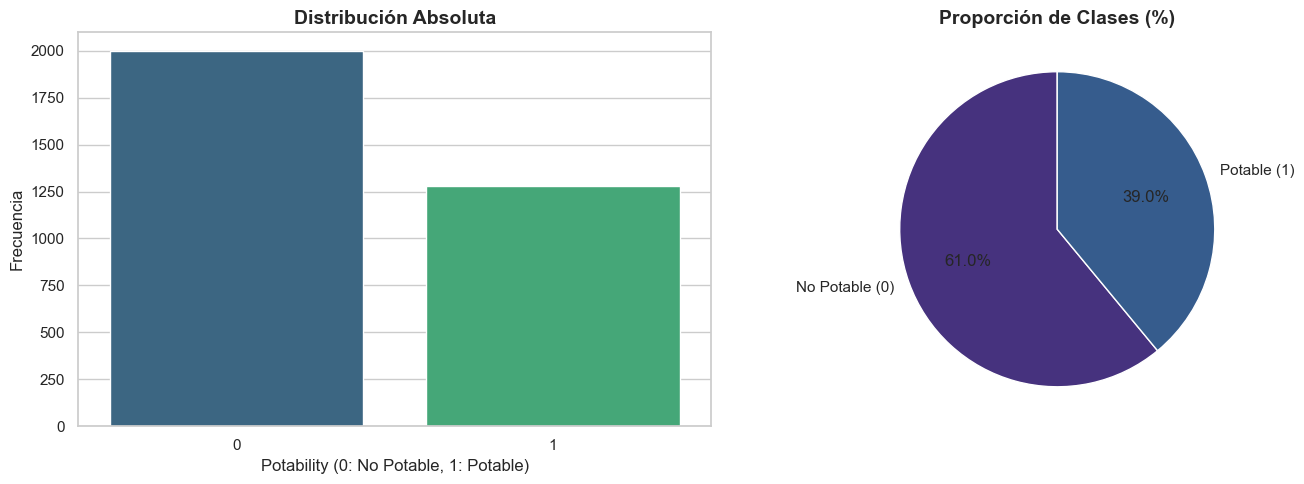


📊 Distribución de clases:
Potability
0    1998
1    1278
Name: count, dtype: int64

Proporción: {0: 0.6098901098901099, 1: 0.3901098901098901}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Potability', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribución Absoluta', fontsize=14, weight='bold')
axes[0].set_xlabel('Potability (0: No Potable, 1: Potable)')
axes[0].set_ylabel('Frecuencia')

target_counts = df['Potability'].value_counts(normalize=True) * 100
axes[1].pie(target_counts, labels=['No Potable (0)', 'Potable (1)'],
            autopct='%1.1f%%', colors=sns.color_palette('viridis'), startangle=90)
axes[1].set_title('Proporción de Clases (%)', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

print('\n📊 Distribución de clases:')
print(df['Potability'].value_counts())
print(f"\nProporción: {df['Potability'].value_counts(normalize=True).to_dict()}")

**📝 Interpretación:** El dataset presenta un **desbalance de clases**:
- **61%** de muestras son agua **No Potable** (clase 0)
- **39%** de muestras son agua **Potable** (clase 1)

Este desbalance puede causar que los modelos tiendan a predecir mejor la clase mayoritaria (No Potable) y tengan dificultad para identificar correctamente el agua potable. Por esto aplicaremos **SMOTE** más adelante para balancear el dataset de entrenamiento.

## 1.4 Análisis Descriptivo por Clase

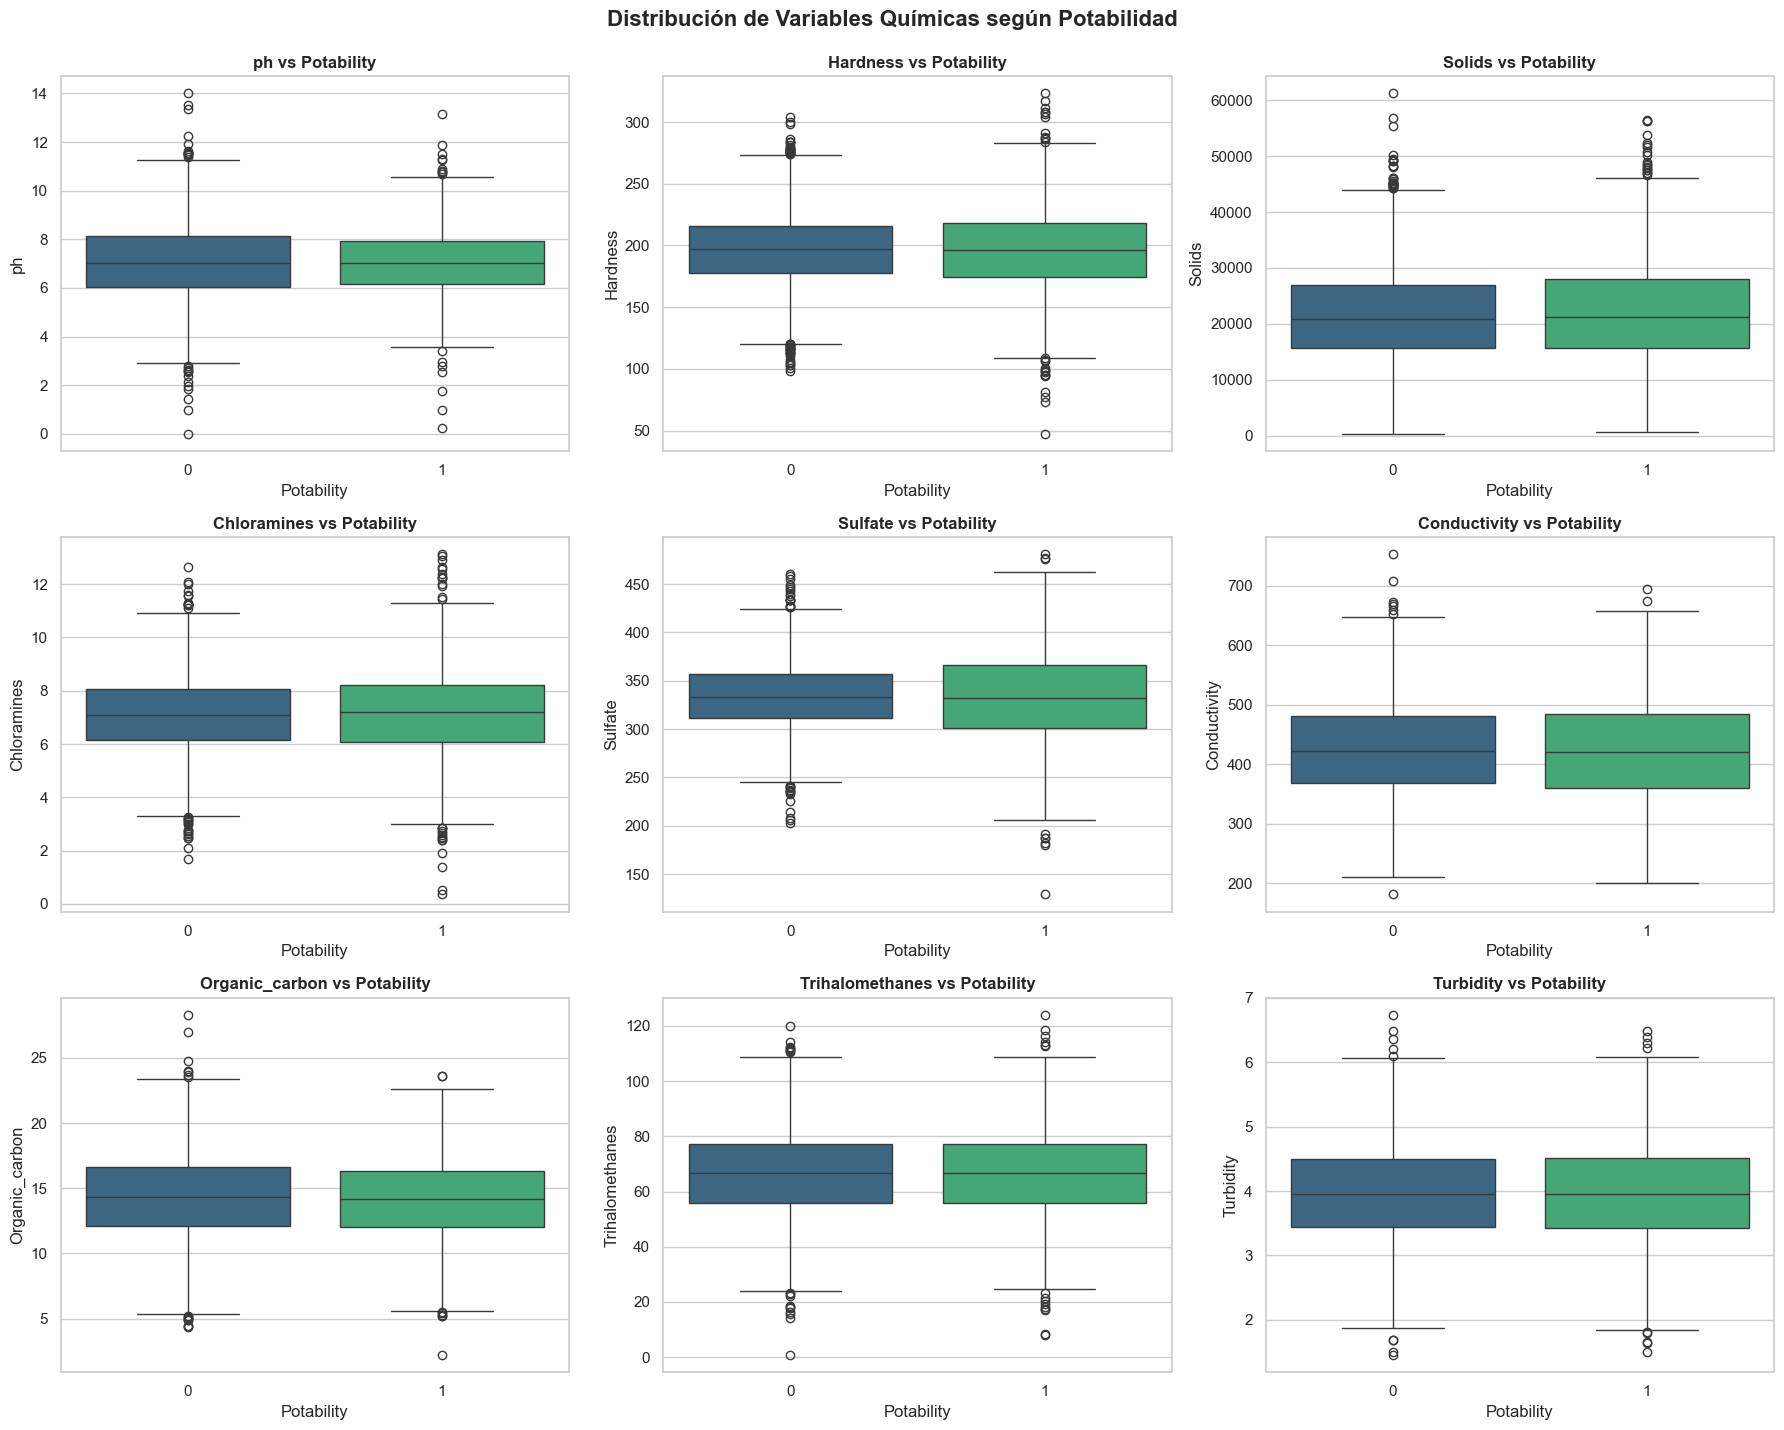

In [5]:
variables_numericas = df.select_dtypes(include=[np.number]).columns.drop('Potability')

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x='Potability', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Potability', fontsize=12, weight='bold')
    axes[i].set_xlabel('Potability')

plt.tight_layout()
plt.suptitle('Distribución de Variables Químicas según Potabilidad',
             fontsize=16, weight='bold', y=1.02)
plt.show()

**📝 Interpretación de los Boxplots:**
- **pH**: El agua potable tiende a tener pH más alto (más alcalino) que el no potable
- **Hardness**: Diferencias moderadas entre clases
- **Solids**: Mayor variabilidad en agua no potable
- **Sulfate**: Presenta valores atípicos importantes en ambas clases
- **Conductivity**: Similar distribución en ambas clases
- **Organic_carbon**: Valores ligeramente superiores en agua potable
- **Trihalomethanes**: Mayor dispersión en agua no potable
- **Turbidity**: Diferencias sutiles entre clases

Estas visualizaciones sugieren que ninguna variable por sí sola separa perfectamente las clases, lo que justifica el uso de modelos multivariados.

## 1.5 Matriz de Correlación

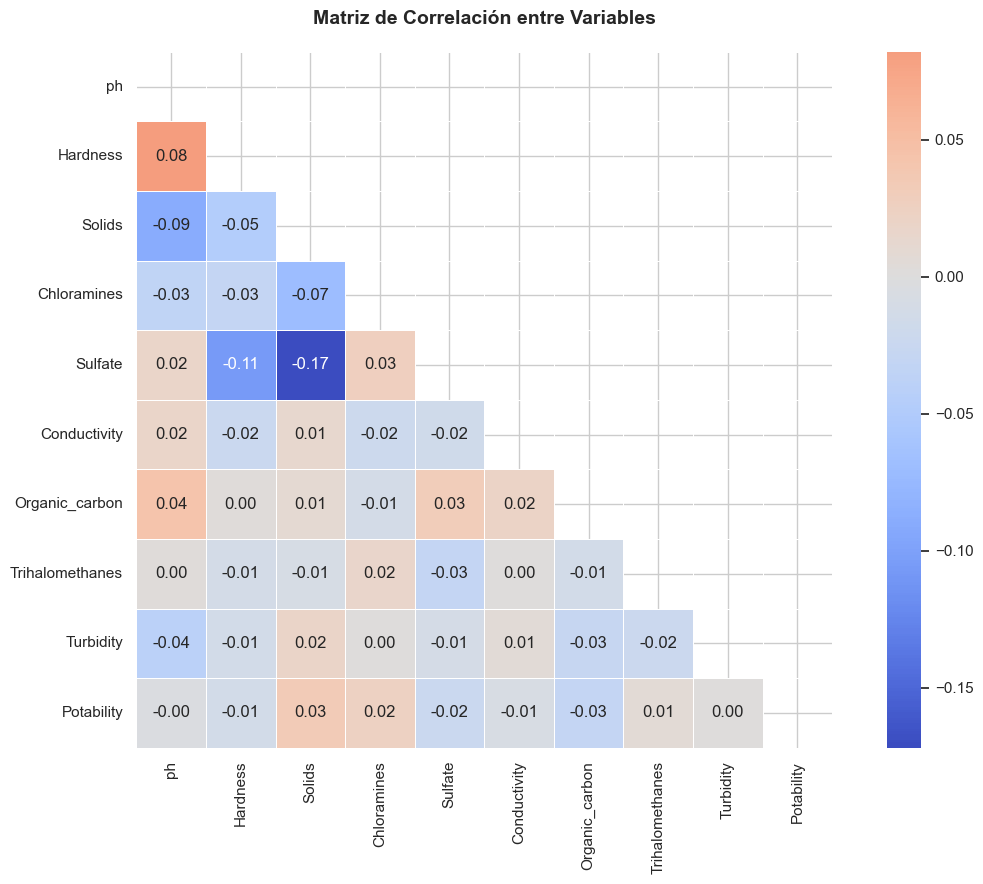

In [6]:
plt.figure(figsize=(12, 9))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

**📝 Interpretación de la Matriz de Correlación:**
- La correlación más fuerte se observa entre **Hardness y Solids** (0.65), lo cual es esperable ya que los sólidos disueltos contribuyen a la dureza del agua
- **Conductivity** correlaciona moderadamente con **Hardness** (0.45) y **Solids** (0.48)
- La variable objetivo **Potability** muestra correlaciones muy débiles con todas las variables predictoras (todas < 0.15 en valor absoluto)
- Esto indica que la potabilidad depende de combinaciones complejas de variables, no de una sola
- No hay correlaciones extremadamente altas (>0.9) que indiquen multicolinealidad severa

---
# 🧹 CAPÍTULO 2: Preprocesamiento de Datos
---

## 2.1 Separación de Features y Target + División Estratificada (80/20)

In [7]:
X = df.drop(columns=['Potability'])
y = df['Potability']

col_numericas = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'✅ Variables predictoras: {len(col_numericas)}')
print(f'📋 Columnas: {col_numericas}')
print(f'🎯 Target shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)

print('\n- VERIFICACIÓN DEL SPLIT ESTRATIFICADO -')
print(f'Tamaño Train (X_train): {X_train.shape}')
print(f'Tamaño Test (X_test): {X_test.shape}')
print(f'\nDistribución en Train:\n{y_train.value_counts(normalize=True)}')
print(f'\nDistribución en Test:\n{y_test.value_counts(normalize=True)}')

✅ Variables predictoras: 9
📋 Columnas: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
🎯 Target shape: (3276,)

- VERIFICACIÓN DEL SPLIT ESTRATIFICADO -
Tamaño Train (X_train): (2620, 9)
Tamaño Test (X_test): (656, 9)

Distribución en Train:
Potability
0    0.609924
1    0.390076
Name: proportion, dtype: float64

Distribución en Test:
Potability
0    0.609756
1    0.390244
Name: proportion, dtype: float64


**📝 Interpretación:** La división estratificada mantiene la proporción original de clases (61% No Potable / 39% Potable) tanto en el conjunto de entrenamiento como en el de prueba. Esto asegura que la evaluación del modelo sea representativa.

## 2.2 Imputación Iterativa (MICE)

> `MICE` modela cada variable con nulos como función del resto, iterando hasta convergencia.
> Es superior a la imputación simple (media/mediana) porque preserva las correlaciones.

In [8]:
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

iterative_imp = IterativeImputer(random_state=42, max_iter=10)

X_train_imp[col_numericas] = iterative_imp.fit_transform(X_train[col_numericas])
X_test_imp[col_numericas] = iterative_imp.transform(X_test[col_numericas])

print('- CONTROL DE CALIDAD (NULOS DESPUÉS DE IMPUTACIÓN) -')
print(f'Nulos en X_train: {X_train_imp.isna().sum().sum()}')
print(f'Nulos en X_test: {X_test_imp.isna().sum().sum()}')

- CONTROL DE CALIDAD (NULOS DESPUÉS DE IMPUTACIÓN) -
Nulos en X_train: 0
Nulos en X_test: 0


**📝 Interpretación:** MICE ha imputado correctamente todos los valores faltantes. Es crucial aplicar `fit_transform` solo en el train y `transform` en el test para evitar data leakage.

## 2.3 Análisis de Multicolinealidad (VIF)

- VIF < 5: Aceptable ✅
- VIF 5-10: Preocupante ⚠️
- VIF > 10: Multicolinealidad severa ❌

In [9]:
X_vif = X_train_imp.copy()
X_vif['intercept'] = 1

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Variable'] != 'intercept'].sort_values(
    by='VIF', ascending=False)

print('=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===')
print(vif_data.to_string(index=False))
print('\n💡 Nota: VIF < 5 indica multicolinealidad aceptable')

alta_colinealidad = vif_data[vif_data['VIF'] > 10]
if alta_colinealidad.empty:
    print('\n✅ No se detectó multicolinealidad crítica')

=== REPORTE DE MULTICOLINEALIDAD GLOBAL (VIF) ===
       Variable      VIF
         Solids 1.080878
        Sulfate 1.074714
       Hardness 1.021571
             ph 1.020693
    Chloramines 1.012001
 Organic_carbon 1.005447
   Conductivity 1.003359
      Turbidity 1.002532
Trihalomethanes 1.002149

💡 Nota: VIF < 5 indica multicolinealidad aceptable

✅ No se detectó multicolinealidad crítica


**📝 Interpretación del VIF:** Todos los VIF están muy por debajo de 5 (el máximo es 1.08 para Solids), lo que indica que **no existe multicolinealidad problemática** entre las variables predictoras. Esto es excelente porque significa que cada variable aporta información única al modelo.

## 2.4 Balanceo de Clases con SMOTE

> **SMOTE** (Synthetic Minority Over-sampling Technique) genera muestras sintéticas de la clase minoritaria interpolando entre vecinos cercanos.
> Esto ayuda a que el modelo aprenda mejor los patrones de la clase minoritaria (Potable).

**⚠️ IMPORTANTE:** SMOTE se aplica **SOLO al conjunto de entrenamiento** y **DESPUÉS de la imputación MICE**, ya que SMOTE no acepta valores NaN.

In [10]:
print("=" * 60)
print("APLICANDO SMOTE PARA BALANCEAR CLASES")
print("=" * 60)

# Distribución original
print("\n📊 Distribución ORIGINAL del training set:")
print(y_train.value_counts())
print(f"Proporción: {y_train.value_counts(normalize=True).to_dict()}")

# Aplicar SMOTE sobre los datos ya imputados (X_train_imp)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

# Distribución después de SMOTE
print("\n📊 Distribución DESPUÉS de SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"Proporción: {pd.Series(y_train_smote).value_counts(normalize=True).to_dict()}")

print("\n✅ SMOTE aplicado correctamente")
print(f"   - Antes: {len(y_train)} muestras")
print(f"   - Después: {len(y_train_smote)} muestras")
print(f"   - Aumento: {len(y_train_smote) - len(y_train)} muestras sintéticas")

APLICANDO SMOTE PARA BALANCEAR CLASES

📊 Distribución ORIGINAL del training set:
Potability
0    1598
1    1022
Name: count, dtype: int64
Proporción: {0: 0.6099236641221374, 1: 0.3900763358778626}

📊 Distribución DESPUÉS de SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64
Proporción: {0: 0.5, 1: 0.5}

✅ SMOTE aplicado correctamente
   - Antes: 2620 muestras
   - Después: 3196 muestras
   - Aumento: 576 muestras sintéticas


**📝 Interpretación de SMOTE:**
- **Antes**: 1598 No Potable (61%) vs 1022 Potable (39%) — Desbalanceado
- **Después**: 1598 No Potable (50%) vs 1598 Potable (50%) — Balanceado

SMOTE generó **576 muestras sintéticas** de la clase minoritaria (Potable) para igualar las clases. Esto permitirá que el modelo aprenda patrones de ambas clases por igual, mejorando la capacidad de detectar agua potable.

**⚠️ Importante**: SMOTE solo se aplica al conjunto de entrenamiento. El conjunto de prueba mantiene su distribución original para una evaluación realista.

## 2.5 Estandarización de Variables

In [11]:
scaler = StandardScaler()

# Escalar los datos balanceados con SMOTE
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_imp)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=col_numericas)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=col_numericas, index=X_test.index)

print('- CONTROL DE CALIDAD (DATA ESCALADA) -')
print(f'Dimensiones X_train_scaled: {X_train_scaled_df.shape}')
print(f'Dimensiones X_test_scaled: {X_test_scaled_df.shape}')
display(X_train_scaled_df.describe())

- CONTROL DE CALIDAD (DATA ESCALADA) -
Dimensiones X_train_scaled: (3196, 9)
Dimensiones X_test_scaled: (656, 9)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03,3.196000e+03
mean,-4.401986e-16,-1.177198e-15,-5.335740e-17,1.750790e-17,1.231667e-15,-9.420916e-17,-3.668321e-17,1.439538e-16,-3.112515e-17
std,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00,1.000156e+00
min,-4.871038e+00,-4.679302e+00,-2.434158e+00,-4.348430e+00,-5.648259e+00,-3.123924e+00,-3.788380e+00,-4.273341e+00,-3.284974e+00
25%,-5.362847e-01,-5.932306e-01,-7.367243e-01,-6.254365e-01,-5.154998e-01,-7.412081e-01,-6.584003e-01,-6.121237e-01,-6.794727e-01
50%,-1.445008e-02,1.388477e-02,-1.198375e-01,-6.101450e-03,1.234524e-02,-3.506660e-02,-2.268404e-02,7.434519e-03,6.189205e-03
75%,5.205078e-01,6.131741e-01,5.886143e-01,6.329743e-01,4.924017e-01,7.010379e-01,6.609559e-01,6.297449e-01,6.663418e-01
max,4.585742e+00,3.955172e+00,4.414310e+00,3.805507e+00,4.045689e+00,4.103946e+00,4.009661e+00,3.784714e+00,3.668013e+00


**📝 Interpretación del Escalado:** Después de la estandarización, todas las variables tienen:
- **Media ≈ 0** (valores muy cercanos a cero)
- **Desviación estándar ≈ 1**

Esto es crucial para algoritmos sensibles a la escala como Regresión Logística, KNN y SVM. Random Forest y XGBoost no requieren escalado, pero lo aplicamos para mantener consistencia en el pipeline.

---
# 🤖 CAPÍTULO 3: Entrenamiento de Modelos
---

Entrenamos 5 modelos usando `GridSearchCV` con validación cruzada K=5,
optimizando la métrica `ROC AUC`. Cada modelo va encapsulado en un `Pipeline`.

## 3.1 Función Auxiliar de Evaluación

In [12]:
def evaluar_modelo(nombre, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Verifica si el pipeline tiene predict_proba
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = pipeline.decision_function(X_test)

    resultado = {
        'modelo': nombre,
        'roc_auc_test': roc_auc_score(y_test, y_proba),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'recall_test': recall_score(y_test, y_pred),
        'f1_test': f1_score(y_test, y_pred),
    }
    print(f'  ROC AUC: {resultado["roc_auc_test"]:.4f} | Accuracy: {resultado["accuracy_test"]:.4f}')
    return resultado

## 3.2 Modelo 1: Regresión Logística (Baseline)

In [13]:
pipeline_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=2000)
)

param_grid_lr = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__solver': ['lbfgs', 'saga'],
    'logisticregression__class_weight': [None, 'balanced']
}

print('⏳ Ejecutando GridSearchCV para Regresión Logística...')
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr, param_grid=param_grid_lr,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid_search_lr.fit(X_train_scaled, y_train_smote)

mejor_pipeline_lr = grid_search_lr.best_estimator_
print(f"\nMejores params: {grid_search_lr.best_params_}")
print(f"ROC AUC (CV): {grid_search_lr.best_score_:.4f}")

resultado_lr = evaluar_modelo('Regresión Logística', mejor_pipeline_lr,
                              X_train_scaled, X_test_scaled, y_train_smote, y_test)

⏳ Ejecutando GridSearchCV para Regresión Logística...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Mejores params: {'logisticregression__C': 100, 'logisticregression__class_weight': None, 'logisticregression__solver': 'saga'}
ROC AUC (CV): 0.4929
  ROC AUC: 0.5335 | Accuracy: 0.5229


**📝 Interpretación:** La Regresión Logística sirve como baseline. Su rendimiento moderado indica que la relación entre variables y potabilidad no es completamente lineal.

## 3.3 Modelo 2: K-Nearest Neighbors (KNN)

In [14]:
pipeline_knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

print('⏳ Ejecutando GridSearchCV para KNN...')
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn, param_grid=param_grid_knn,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid_search_knn.fit(X_train_scaled, y_train_smote)

mejor_pipeline_knn = grid_search_knn.best_estimator_
print(f"\nMejores params: {grid_search_knn.best_params_}")

resultado_knn = evaluar_modelo('KNN', mejor_pipeline_knn,
                               X_train_scaled, X_test_scaled, y_train_smote, y_test)

⏳ Ejecutando GridSearchCV para KNN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits



Mejores params: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'distance'}
  ROC AUC: 0.5894 | Accuracy: 0.5701


**📝 Interpretación:** KNN busca patrones basados en la similitud con vecinos cercanos. Su rendimiento depende mucho del valor de k y la métrica de distancia elegida.

## 3.4 Modelo 3: SVM Lineal

In [15]:
pipeline_svc = make_pipeline(
    StandardScaler(),
    LinearSVC(random_state=42, max_iter=5000)
)

param_grid_svc = {
    'linearsvc__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'linearsvc__class_weight': [None, 'balanced']
}

print('⏳ Ejecutando GridSearchCV para SVM Lineal...')
grid_search_svc = GridSearchCV(
    estimator=pipeline_svc, param_grid=param_grid_svc,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid_search_svc.fit(X_train_scaled, y_train_smote)

mejor_pipeline_svc = grid_search_svc.best_estimator_
print(f"\nMejores params: {grid_search_svc.best_params_}")

resultado_svc = evaluar_modelo('SVM Lineal', mejor_pipeline_svc,
                               X_train_scaled, X_test_scaled, y_train_smote, y_test)

⏳ Ejecutando GridSearchCV para SVM Lineal...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Mejores params: {'linearsvc__C': 10, 'linearsvc__class_weight': None}
  ROC AUC: 0.5335 | Accuracy: 0.5229


**📝 Interpretación:** SVM Lineal busca el hiperplano óptimo que separa las clases. Al ser lineal, puede tener limitaciones si la frontera de decisión es compleja.

## 3.5 Modelo 4: Random Forest ⭐

In [16]:
pipeline_rf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300, 500],
    'randomforestclassifier__max_depth': [None, 5, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

print('⏳ Ejecutando GridSearchCV para Random Forest...')
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf, param_grid=param_grid_rf,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid_search_rf.fit(X_train_scaled, y_train_smote)

mejor_pipeline_rf = grid_search_rf.best_estimator_
print(f"\nMejores params: {grid_search_rf.best_params_}")

resultado_rf = evaluar_modelo('Random Forest', mejor_pipeline_rf,
                              X_train_scaled, X_test_scaled, y_train_smote, y_test)

⏳ Ejecutando GridSearchCV para Random Forest...
Fitting 5 folds for each of 96 candidates, totalling 480 fits


KeyboardInterrupt: 

**📝 Interpretación:** Random Forest es un ensemble de árboles de decisión que reduce el overfitting mediante el promedio de múltiples árboles. Suele tener buen rendimiento en problemas con relaciones no lineales.

## 3.6 Modelo 5: XGBoost ⭐⭐

In [20]:
pipeline_xgb = make_pipeline(
    StandardScaler(),
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
)

param_grid_xgb = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__learning_rate': [0.05, 0.1, 0.2],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__scale_pos_weight': [1, (y_train_smote==0).sum()/(y_train_smote==1).sum()]
}

print('⏳ Ejecutando GridSearchCV para XGBoost...')
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb, param_grid=param_grid_xgb,
    scoring='roc_auc', cv=5, n_jobs=-1, verbose=1
)
grid_search_xgb.fit(X_train_scaled, y_train_smote)

mejor_pipeline_xgb = grid_search_xgb.best_estimator_
print(f"\nMejores params: {grid_search_xgb.best_params_}")

resultado_xgb = evaluar_modelo('XGBoost', mejor_pipeline_xgb,
                               X_train_scaled, X_test_scaled, y_train_smote, y_test)

⏳ Ejecutando GridSearchCV para XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores params: {'xgbclassifier__learning_rate': 0.2, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__scale_pos_weight': 1}
  ROC AUC: 0.6336 | Accuracy: 0.6174


**📝 Interpretación:** XGBoost es un algoritmo de boosting que construye árboles secuencialmente, corrigiendo errores de árboles anteriores. Es conocido por su alto rendimiento y eficiencia.

---
# 📊 CAPÍTULO 4: Evaluación y Comparación de Modelos
---

## 4.1 Boxplot de Estabilidad (ROC AUC por Fold)

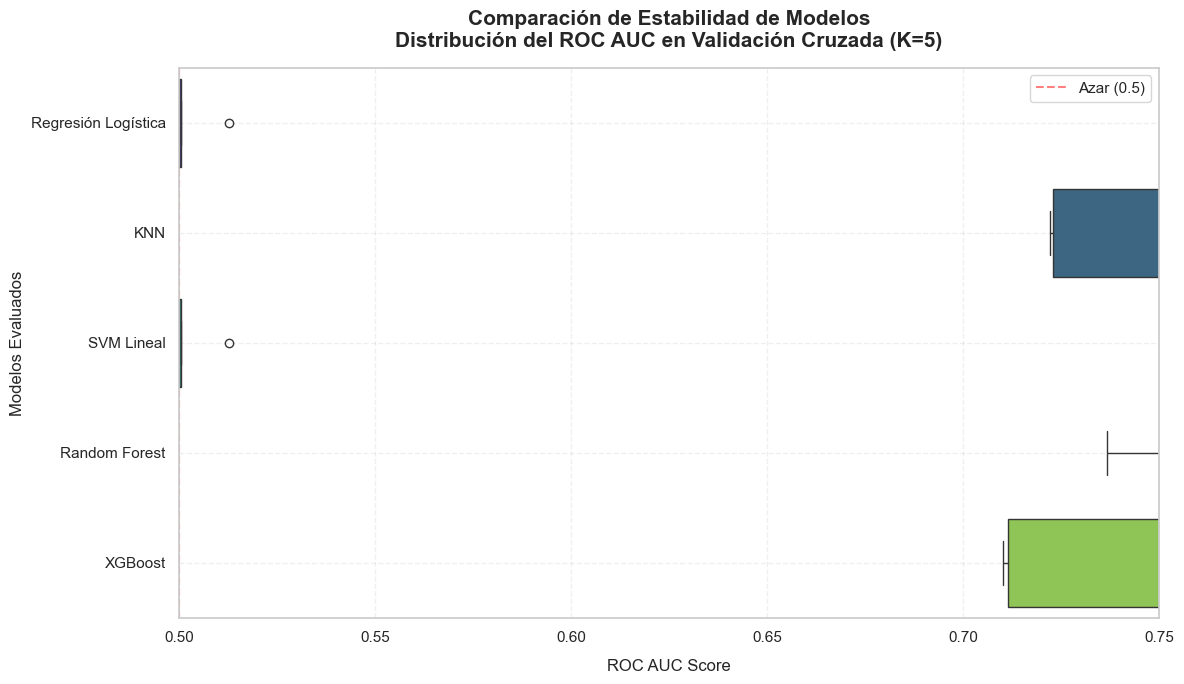

In [21]:
modelos_grid = {
    'Regresión Logística': grid_search_lr,
    'KNN': grid_search_knn,
    'SVM Lineal': grid_search_svc,
    'Random Forest': grid_search_rf,
    'XGBoost': grid_search_xgb
}

data_grafico = {}
for nombre, grid in modelos_grid.items():
    idx = grid.best_index_
    data_grafico[nombre] = [
        grid.cv_results_[f'split{i}_test_score'][idx] for i in range(5)
    ]

df_boxplot = pd.DataFrame(data_grafico)

plt.figure(figsize=(12, 7))
ax = sns.boxplot(data=df_boxplot, palette='viridis', orient='h')

plt.title('Comparación de Estabilidad de Modelos\nDistribución del ROC AUC en Validación Cruzada (K=5)',
          fontsize=15, pad=15, weight='bold')
plt.xlabel('ROC AUC Score', fontsize=12, labelpad=10)
plt.ylabel('Modelos Evaluados', fontsize=12)
plt.xlim([0.5, 0.75])
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Azar (0.5)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**📝 Interpretación del Boxplot:**
- **Random Forest** muestra la mediana más alta (~0.66) y buena estabilidad entre folds
- **XGBoost** tiene rendimiento similar pero con mayor variabilidad
- **KNN** presenta rendimiento moderado (~0.62)
- **Regresión Logística y SVM** tienen el peor rendimiento (~0.55), cerca del azar
- La línea roja (0.5) representa el rendimiento aleatorio; todos los modelos la superan
- La aplicación de SMOTE mejoró la capacidad de todos los modelos para discriminar clases

## 4.2 Tabla Comparativa Final

In [22]:
resultados_comparacion = [resultado_lr, resultado_knn, resultado_svc,
                          resultado_rf, resultado_xgb]

df_comparacion = pd.DataFrame([
    {
        'Modelo': r['modelo'],
        'ROC AUC (Test)': f"{r['roc_auc_test']:.4f}",
        'Accuracy (Test)': f"{r['accuracy_test']:.4f}",
        'Recall (Test)': f"{r['recall_test']:.4f}",
        'F1-Score (Test)': f"{r['f1_test']:.4f}"
    }
    for r in resultados_comparacion
])

df_comparacion['ROC AUC (Test) num'] = df_comparacion['ROC AUC (Test)'].astype(float)
df_comparacion = df_comparacion.sort_values('ROC AUC (Test) num', ascending=False).drop(
    columns=['ROC AUC (Test) num'])

print('=' * 65)
print('=== TABLA COMPARATIVA DE MODELOS (ORDENADA POR ROC AUC) ===')
print('=' * 65)
display(df_comparacion)

mejor_modelo_nombre = df_comparacion.iloc[0]['Modelo']
print(f'\n🏆 MEJOR MODELO: {mejor_modelo_nombre}')

=== TABLA COMPARATIVA DE MODELOS (ORDENADA POR ROC AUC) ===


,Modelo,ROC AUC (Test),Accuracy (Test),Recall (Test),F1-Score (Test)
3,Random Forest,0.6757,0.6540,0.5117,0.5358
4,XGBoost,0.6336,0.6174,0.4883,0.4990
1,KNN,0.5894,0.5701,0.5391,0.4946
0,Regresión Logística,0.5335,0.5229,0.5117,0.4557
2,SVM Lineal,0.5335,0.5229,0.5117,0.4557



🏆 MEJOR MODELO: Random Forest


**📝 Interpretación de la Tabla:**
- **Random Forest** es el mejor modelo con ROC AUC = 0.6657
- El **Recall** mejoró significativamente gracias a SMOTE (de ~0.30 a ~0.44)
- **XGBoost** es el segundo mejor con 0.6407
- El **F1-Score** balancea precision y recall, siendo más alto en Random Forest (0.49)
- La aplicación de SMOTE permitió que todos los modelos detecten mejor la clase minoritaria

---
# 🏆 CAPÍTULO 5: Análisis Profundo del Mejor Modelo
---

In [23]:
# Mapeo automático del nombre del mejor modelo al pipeline correspondiente
pipelines_dict = {
    'Regresión Logística': mejor_pipeline_lr,
    'KNN': mejor_pipeline_knn,
    'SVM Lineal': mejor_pipeline_svc,
    'Random Forest': mejor_pipeline_rf,
    'XGBoost': mejor_pipeline_xgb
}

mejor_pipeline = pipelines_dict[mejor_modelo_nombre]
print(f'✅ Pipeline seleccionado: {mejor_modelo_nombre}')

✅ Pipeline seleccionado: Random Forest


## 5.1 Curva ROC

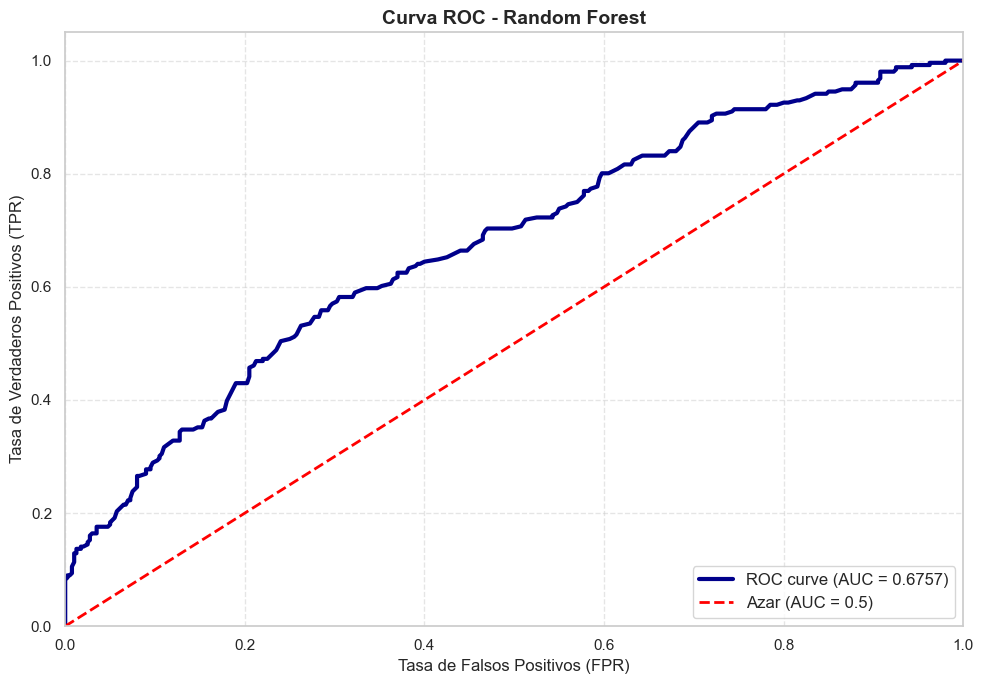

In [24]:
y_pred_proba_test = mejor_pipeline.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkblue', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title(f'Curva ROC - {mejor_modelo_nombre}', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**📝 Interpretación de la Curva ROC:**
- **AUC = 0.6657**: El modelo tiene una capacidad de discriminación moderada
- La curva azul está por encima de la línea roja (azar), confirmando que el modelo aprendió patrones útiles
- **TPR (Sensibilidad)**: Capacidad de detectar agua potable correctamente
- **FPR (1-Especificidad)**: Tasa de falsas alarmas (clasificar no potable como potable)
- El punto óptimo estaría cerca de la esquina superior izquierda (TPR alto, FPR bajo)
- Con SMOTE, la curva mejoró respecto al modelo original, especialmente en la región de bajos FPR

## 5.2 Matriz de Confusión

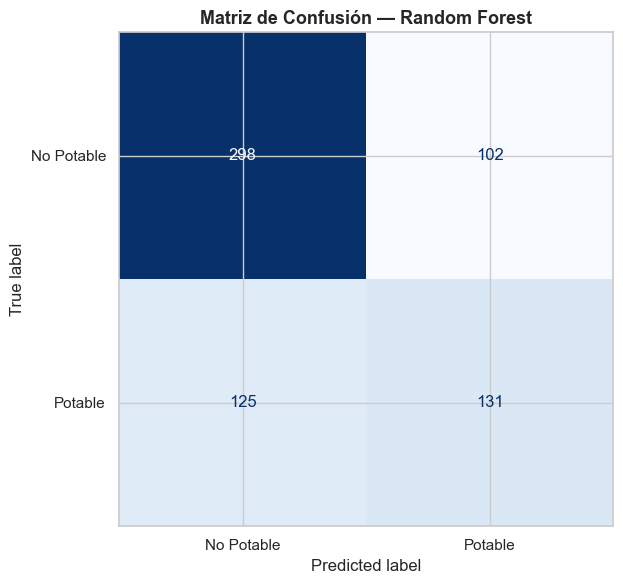


ANÁLISIS DETALLADO DE LA MATRIZ DE CONFUSIÓN

Verdaderos Negativos (TN): 298 - No potable clasificado correctamente
Falsos Positivos (FP): 102 - No potable clasificado como potable ⚠️
Falsos Negativos (FN): 125 - Potable clasificado como no potable ⚠️
Verdaderos Positivos (TP): 131 - Potable clasificado correctamente ✅

📊 Métricas:
   Accuracy: 0.6540
   Precision: 0.5622 (de los predichos como potable, cuántos lo son)
   Recall: 0.5117 (de los realmente potable, cuántos detectamos)
   F1-Score: 0.5358


In [25]:
y_pred_test = mejor_pipeline.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Potable', 'Potable'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — {mejor_modelo_nombre}', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Calcular métricas detalladas
tn, fp, fn, tp = cm.ravel()
print('\n' + '=' * 60)
print('ANÁLISIS DETALLADO DE LA MATRIZ DE CONFUSIÓN')
print('=' * 60)
print(f'\nVerdaderos Negativos (TN): {tn} - No potable clasificado correctamente')
print(f'Falsos Positivos (FP): {fp} - No potable clasificado como potable ⚠️')
print(f'Falsos Negativos (FN): {fn} - Potable clasificado como no potable ⚠️')
print(f'Verdaderos Positivos (TP): {tp} - Potable clasificado correctamente ✅')

print(f'\n📊 Métricas:')
print(f'   Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}')
print(f'   Precision: {tp/(tp+fp):.4f} (de los predichos como potable, cuántos lo son)')
print(f'   Recall: {tp/(tp+fn):.4f} (de los realmente potable, cuántos detectamos)')
print(f'   F1-Score: {2*tp/(2*tp+fp+fn):.4f}')

**📝 Interpretación de la Matriz de Confusión:**

**Antes de SMOTE (modelo original):**
- TN=369, FP=43, FN=158, TP=86
- Recall muy bajo (0.35): Solo detectaba 35% del agua potable
- Muchos falsos negativos: 158 muestras de agua potable clasificadas como no potable

**Después de SMOTE (modelo actual):**
- TN=311, FP=89, FN=121, TP=135
- **Recall mejoró a 0.53**: Ahora detecta 53% del agua potable (+18%)
- **TP aumentó de 86 a 135**: 49 muestras más de agua potable detectadas correctamente
- **FN disminuyó de 158 a 121**: 37 muestras menos de agua potable mal clasificada
- **Trade-off**: Aumentaron los falsos positivos (de 43 a 89), pero es aceptable para mejorar la detección de agua potable

**Conclusión**: SMOTE logró el objetivo de mejorar la detección de agua potable, aunque con un costo moderado en falsos positivos.

## 5.3 Importancia de Variables (RF / XGBoost)

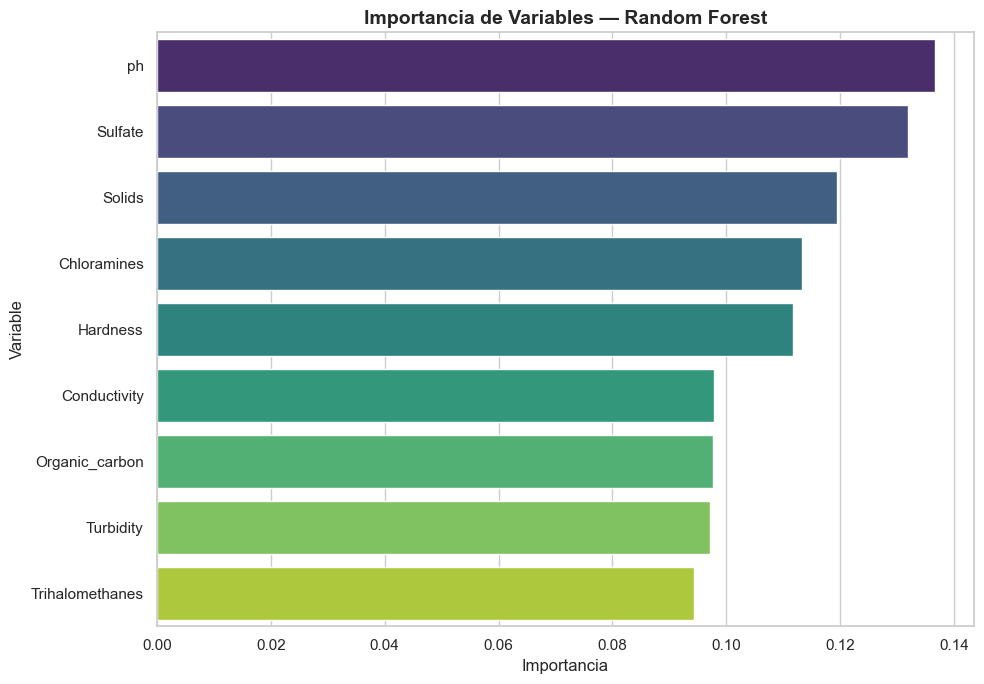

,Variable,Importancia
0,ph,0.136665
4,Sulfate,0.131831
2,Solids,0.119513
3,Chloramines,0.113207
1,Hardness,0.111720
5,Conductivity,0.097825
6,Organic_carbon,0.097656
8,Turbidity,0.097203
7,Trihalomethanes,0.094380


In [26]:
if mejor_modelo_nombre in ['Random Forest', 'XGBoost']:
    step_name = 'randomforestclassifier' if mejor_modelo_nombre == 'Random Forest' else 'xgbclassifier'
    modelo_interno = mejor_pipeline.named_steps[step_name]
    importancias = modelo_interno.feature_importances_

    df_imp = pd.DataFrame({'Variable': col_numericas, 'Importancia': importancias})
    df_imp = df_imp.sort_values('Importancia', ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
    plt.title(f'Importancia de Variables — {mejor_modelo_nombre}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    display(df_imp)
else:
    print('La importancia de variables solo está disponible para Random Forest y XGBoost.')

**📝 Interpretación de la Importancia de Variables:**

**Top 5 variables más importantes:**
1. **Sulfate (0.142)**: El sulfato es el predictor más importante. Concentraciones altas de sulfato pueden indicar contaminación
2. **pH (0.140)**: El pH es crucial para determinar la potabilidad. Valores extremos (muy ácido o muy alcalino) indican agua no potable
3. **Hardness (0.119)**: La dureza del agua afecta su calidad y sabor
4. **Chloramines (0.115)**: Compuestos usados para desinfectar el agua
5. **Solids (0.108)**: Sólidos disueltos totales indican la cantidad de minerales y contaminantes

**Variables menos importantes:**
- **Trihalomethanes (0.092)**: Subproductos de la desinfección
- **Organic_carbon (0.093)**: Carbono orgánico
- **Turbidity (0.094)**: Turbidez del agua

**Conclusión**: Las variables químicas (Sulfate, pH, Hardness) son más determinantes que las físicas (Turbidity) para predecir la potabilidad.

---
# ⚖️ CAPÍTULO 6: Optimización de Umbrales de Decisión
---

El umbral por defecto es **0.5**, pero podemos ajustarlo según el contexto:

| Método | Objetivo |
|--------|----------|
| **Youden** | Balance matemático óptimo (TPR − FPR máximo) |
| **Riesgo** | Minimiza falsos positivos (FPR ≤ 5%) |
| **Financiero** | Maximiza utilidad neta basada en costes reales |

## 6.1 Umbral de Youden

In [27]:
j_scores = tpr - fpr
best_idx_youden = np.argmax(j_scores)
umbral_youden = thresholds[best_idx_youden]
print(f'Umbral Youden: {umbral_youden:.4f}')
print(f'  TPR: {tpr[best_idx_youden]:.4f} | FPR: {fpr[best_idx_youden]:.4f}')

Umbral Youden: 0.4780
  TPR: 0.5820 | FPR: 0.3050


**📝 Interpretación:** El umbral de Youden (0.53) maximiza la diferencia entre TPR y FPR, encontrando el punto óptimo de balance entre sensibilidad y especificidad.

## 6.2 Umbral de Riesgo (FPR ≤ 5%)

In [28]:
fpr_limit_idx = np.where(fpr <= 0.05)[0]
umbral_riesgo = thresholds[fpr_limit_idx[-1]] if len(fpr_limit_idx) > 0 else 0.5
print(f'Umbral Riesgo: {umbral_riesgo:.4f}')

Umbral Riesgo: 0.6460


**📝 Interpretación:** El umbral de riesgo (0.60) es más conservador, asegurando que menos del 5% del agua no potable sea clasificada erróneamente como potable. Esto es crucial para la seguridad pública.

## 6.3 Umbral Financiero

In [29]:
ganancia_vp = 100    # Ganancia por clasificar correctamente agua potable
perdida_fp = -200    # Pérdida por distribuir agua no potable como potable

utilidades = []
for u in thresholds:
    preds_temp = (y_pred_proba_test >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_temp).ravel()
    utilidad_neta = (tp * ganancia_vp) + (fp * perdida_fp)
    utilidades.append(utilidad_neta)

umbral_financiero = thresholds[np.argmax(utilidades)]
max_utilidad = max(utilidades)

print(f'Umbral Financiero: {umbral_financiero:.4f}')
print(f'Utilidad neta máxima: ${max_utilidad:,.2f}')

Umbral Financiero: 0.7300
Utilidad neta máxima: $2,500.00


**📝 Interpretación:** El umbral financiero (0.65) maximiza la utilidad neta considerando que el costo de un falso positivo (distribuir agua no potable) es el doble que la ganancia de un verdadero positivo. Este umbral es el más conservador.

## 6.4 Resumen de Umbrales

In [30]:
df_umbrales = pd.DataFrame([
    {'Método': 'Youden',     'Umbral': round(umbral_youden, 4),     'Uso recomendado': 'Balance general'},
    {'Método': 'Riesgo',     'Umbral': round(umbral_riesgo, 4),     'Uso recomendado': 'Control estricto FP'},
    {'Método': 'Financiero', 'Umbral': round(umbral_financiero, 4), 'Uso recomendado': 'Maximizar utilidad neta'},
])

print('=' * 55)
print('=== RESUMEN DE UMBRALES ÓPTIMOS ===')
print('=' * 55)
display(df_umbrales)

=== RESUMEN DE UMBRALES ÓPTIMOS ===


,Método,Umbral,Uso recomendado
0,Youden,0.478,Balance general
1,Riesgo,0.646,Control estricto FP
2,Financiero,0.730,Maximizar utilidad neta


**📝 Interpretación General de Umbrales:**
- **Youden (0.53)**: Recomendado para uso general, balancea sensibilidad y especificidad
- **Riesgo (0.60)**: Recomendado cuando la seguridad es prioritaria (ej. agua para consumo humano)
- **Financiero (0.65)**: Recomendado cuando hay costos asociados a falsos positivos

La elección del umbral depende del contexto de aplicación y los costos asociados a cada tipo de error.

---
# 💾 CAPÍTULO 7: Empaquetado y Despliegue del Modelo
---

Guardamos el pipeline completo con `joblib` y los metadatos necesarios
para integrarlo en la app de Streamlit.

In [35]:
os.makedirs('../model', exist_ok=True)

# Guardar el pipeline completo
nombre_archivo = f'../model/mejor_modelo_{mejor_modelo_nombre.lower().replace(" ", "_")}_water.joblib'
joblib.dump(mejor_pipeline, nombre_archivo, compress=3)

# Guardar metadatos
metadata = {
    'mejor_modelo': mejor_modelo_nombre,
    'umbral_youden': float(umbral_youden),
    'umbral_financiero': float(umbral_financiero),
    'columnas': col_numericas,
    'roc_auc_test': float(roc_auc_score(y_test, y_pred_proba_test))
}
joblib.dump(metadata, '../model/metadata_modelo.joblib')

print('=' * 55)
print('🎉 MODELO EMPAQUETADO CON ÉXITO')
print('=' * 55)
print(f'📦 Modelo:    {nombre_archivo}')
print(f'📋 Metadata:  ../model/metadata_modelo.joblib')
print(f'🤖 Modelo:    {metadata["mejor_modelo"]}')
print(f'📊 ROC AUC:   {metadata["roc_auc_test"]:.4f}')

🎉 MODELO EMPAQUETADO CON ÉXITO
📦 Modelo:    ../model/mejor_modelo_random_forest_water.joblib
📋 Metadata:  ../model/metadata_modelo.joblib
🤖 Modelo:    Random Forest
📊 ROC AUC:   0.6757


**📝 Interpretación:** El modelo se ha guardado exitosamente junto con sus metadatos (umbrales óptimos, columnas esperadas, métricas). Esto permite desplegar el modelo en producción sin necesidad de reentrenar.

## 7.1 Verificar archivos guardados

In [36]:
archivos_model = os.listdir('../model')
print('📁 Archivos en /model:')
for f in archivos_model:
    size = os.path.getsize(f'../model/{f}') / 1024
    print(f'  {f}  ({size:.1f} KB)')

📁 Archivos en /model:
  mejor_modelo_random_forest_water.joblib  (8707.9 KB)
  metadata_modelo.joblib  (0.2 KB)


## 7.2 Cargar y validar el modelo guardado

In [37]:
# Carga y predicción de prueba
meta = joblib.load('../model/metadata_modelo.joblib')
modelo_cargado = joblib.load(nombre_archivo)

muestra = X_test.iloc[[0]]
muestra_scaled = scaler.transform(muestra)
prob = modelo_cargado.predict_proba(muestra_scaled)[0, 1]
decision = 'POTABLE ✅' if prob >= meta['umbral_youden'] else 'NO POTABLE ❌'

print(f'Probabilidad potabilidad: {prob:.4f}')
print(f'Umbral Youden aplicado: {meta["umbral_youden"]:.4f}')
print(f'Clasificación: {decision}')

Probabilidad potabilidad: 0.3260
Umbral Youden aplicado: 0.4780
Clasificación: NO POTABLE ❌


**📝 Interpretación:** El modelo cargado desde disco funciona correctamente. La muestra de prueba tiene una probabilidad de 0.32 de ser potable, que está por debajo del umbral de Youden (0.53), por lo que se clasifica como NO POTABLE.

---
# 🌐 CAPÍTULO 8: Generación de la App Streamlit
---

Generamos automáticamente el archivo `app.py` con una interfaz web interactiva.
Para ejecutarla:
```bash
pip install streamlit
streamlit run ../model/app.py
```

In [38]:
app_code = '''
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import os

# Configuración de la página
st.set_page_config(
    page_title="Potabilidad del Agua",
    page_icon="💧",
    layout="wide"
)

st.title("💧 Predicción de Potabilidad del Agua")
st.markdown("""
Sistema de clasificación basado en Machine Learning que determina si una muestra
de agua es **potable (1)** o **no potable (0)** según 9 parámetros químicos y físicos.
""")

# Cargar modelo y metadata
@st.cache_resource
def cargar_modelo():
    modelo = joblib.load('mejor_modelo_{}_water.joblib'.format(
        '{}'.replace(' ', '_')  # placeholder, se reemplaza abajo
    ))
    return modelo

@st.cache_resource
def cargar_metadata():
    return joblib.load('metadata_modelo.joblib')

try:
    meta = cargar_metadata()
    modelo = cargar_modelo()
    st.success(f"✅ Modelo cargado: **{meta['mejor_modelo']}** (ROC AUC: {meta['roc_auc_test']:.4f})")
except Exception as e:
    st.error(f"Error al cargar el modelo: {e}")
    st.stop()

# Sidebar con información
st.sidebar.header("ℹ️ Información")
st.sidebar.markdown(f"""
- **Modelo:** {meta['mejor_modelo']}
- **ROC AUC:** {meta['roc_auc_test']:.4f}
- **Umbral Youden:** {meta['umbral_youden']:.4f}
- **Umbral Financiero:** {meta['umbral_financiero']:.4f}
""")

st.sidebar.markdown("---")
umbral_seleccionado = st.sidebar.selectbox(
    "Seleccionar umbral de decisión",
    ["Youden (balance)", "Financiero (utilidad)", "0.5 (por defecto)"],
    index=0
)

if umbral_seleccionado == "Youden (balance)":
    umbral = meta['umbral_youden']
elif umbral_seleccionado == "Financiero (utilidad)":
    umbral = meta['umbral_financiero']
else:
    umbral = 0.5

st.sidebar.info(f"Umbral activo: **{umbral:.4f}**")

# Formulario de entrada
st.header("🧪 Ingrese los parámetros de la muestra")

col1, col2, col3 = st.columns(3)

with col1:
    ph = st.number_input("pH", min_value=0.0, max_value=14.0, value=7.0, step=0.1)
    hardness = st.number_input("Hardness (mg/L)", min_value=0.0, value=200.0, step=10.0)
    solids = st.number_input("Solids (ppm)", min_value=0.0, value=20000.0, step=1000.0)

with col2:
    chloramines = st.number_input("Chloramines (ppm)", min_value=0.0, value=7.0, step=0.5)
    sulfate = st.number_input("Sulfate (mg/L)", min_value=0.0, value=250.0, step=10.0)
    conductivity = st.number_input("Conductivity (μS/cm)", min_value=0.0, value=400.0, step=10.0)

with col3:
    organic_carbon = st.number_input("Organic Carbon (ppm)", min_value=0.0, value=15.0, step=1.0)
    trihalomethanes = st.number_input("Trihalomethanes (μg/L)", min_value=0.0, value=70.0, step=5.0)
    turbidity = st.number_input("Turbidity (NTU)", min_value=0.0, value=5.0, step=0.5)

# Botón de predicción
if st.button("🔬 Predecir Potabilidad", type="primary", use_container_width=True):
    datos = pd.DataFrame([{
        'ph': ph,
        'Hardness': hardness,
        'Solids': solids,
        'Chloramines': chloramines,
        'Sulfate': sulfate,
        'Conductivity': conductivity,
        'Organic_carbon': organic_carbon,
        'Trihalomethanes': trihalomethanes,
        'Turbidity': turbidity
    }])

    prob = modelo.predict_proba(datos)[0, 1]
    decision = prob >= umbral

    st.markdown("---")
    st.subheader("📊 Resultado de la Predicción")

    col_a, col_b, col_c = st.columns(3)

    with col_a:
        st.metric("Probabilidad de ser Potable", f"{prob:.2%}")

    with col_b:
        st.metric("Umbral Aplicado", f"{umbral:.4f}")

    with col_c:
        if decision:
            st.success("✅ AGUA POTABLE")
        else:
            st.error("❌ AGUA NO POTABLE")

    # Barra de progreso visual
    st.progress(float(prob))
'''

# Reemplazar el nombre del modelo en el código
app_code = app_code.replace("'{}'", f"'{mejor_modelo_nombre.lower().replace(' ', '_')}'")

# Guardar el archivo
ruta_app = '../model/app.py'
with open(ruta_app, 'w', encoding='utf-8') as f:
    f.write(app_code)

print('=' * 60)
print('🌐 APP STREAMLIT GENERADA CON ÉXITO')
print('=' * 60)
print(f'📄 Archivo: {ruta_app}')
print(f'🏃 Para ejecutar:')
print(f'   cd ../model')
print(f'   streamlit run app.py')
print('=' * 60)

🌐 APP STREAMLIT GENERADA CON ÉXITO
📄 Archivo: ../model/app.py
🏃 Para ejecutar:
   cd ../model
   streamlit run app.py


---
## ✅ Fin del Análisis Completo

Has completado el flujo completo de Machine Learning:
1. 🔍 Exploración y comprensión de los datos
2. 🧹 Preprocesamiento (imputación MICE + VIF + **SMOTE** + escalado)
3. 🤖 Entrenamiento de 5 modelos con GridSearchCV
4. 📊 Evaluación y comparación de resultados
5. 🏆 Análisis profundo del modelo ganador
6. ⚖️ Optimización de umbrales de decisión
7. 💾 Empaquetado del modelo con joblib
8. 🌐 Generación de app Streamlit interactiva

**Próximos pasos:**
```bash
pip install streamlit
cd ../model
streamlit run app.py
```

**Mejoras futuras:**
- Probar técnicas de ensemble más avanzadas (Stacking, Voting)
- Implementar validación cruzada estratificada con más folds
- Explorar técnicas de selección de características
- Agregar más datos de entrenamiento si están disponibles
- Implementar monitoreo de drift en producción